<div style="text-align: center">
    <h2><font size=6>Dataset Tesis Imágenes Enfermedades Oculares</font></h2>
</d>
</div>

**Objetivo:**
Recolectar y preparar un dataset balanceado con imágenes de fondo de ojo correspondientes a seis clases: degeneración macular relacionada con la edad, catarata, glaucoma, miopía, retinopatía diabética y sanos, aplicando técnicas de preprocesamiento y aumento de datos.

El dataset se consolidó a partir de cuatro fuentes internacionales de acceso público, garantizando diversidad clínica y validación profesional.
* Kaggle: Eye Diseases
* ODIR-5K
* Mendeley Dataset
* MuReD Dataset

Las imágenes del dataset, estan distribuidas entre las seis principales enfermedades oculares en Perú y las imágenes de enfermedades encontrados: 
* Age Degeneration     -> 0
* Myopia               -> 1
* Cataract             -> 2
* Diabetic Retinopathy -> 3
* Glaucoma             -> 4
* Healthy              -> 5

 ***Etiquetas**: Codificación de etiquetas --> Números*

**VISUALIZACIÓN DE IMÁGENES POR CLASE**

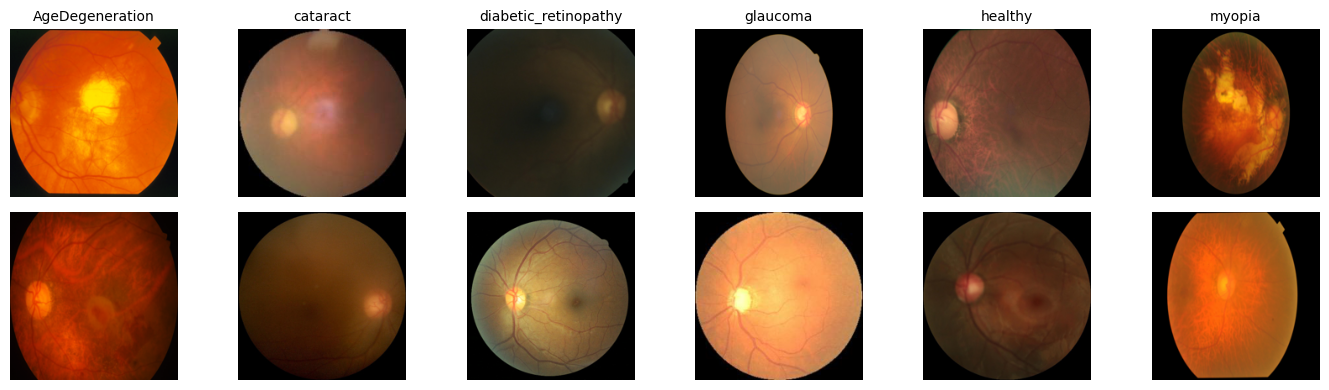

In [1]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

DATASET_PATH = "dataset"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "myopia"
]


fig, axes = plt.subplots(2, len(classes), figsize=(14, 4))

for col, cls in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, cls)
    
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    
    selected_images = random.sample(images, 2)
    
    for row, img_name in enumerate(selected_images):
        img_path = os.path.join(class_path, img_name)
        
        # Redimensionado solo para visualización
        img = Image.open(img_path).resize((200, 200))
        
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        
        if row == 0:
        axes[row, col].set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()

**CANTIDAD DE IMÁGENES**

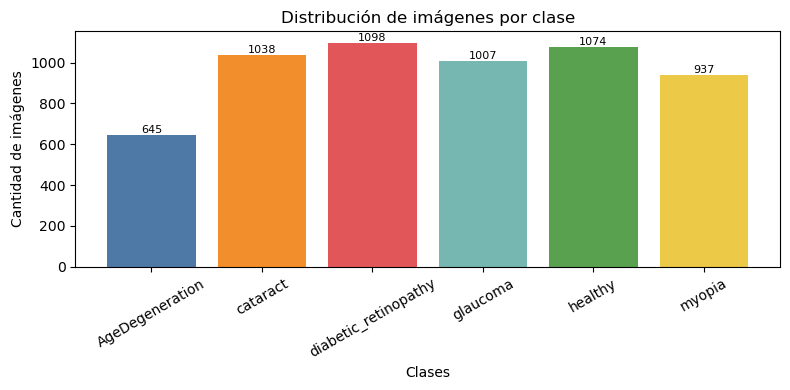

Cantidad de imágenes por clase:
- AgeDegeneration: 645
- cataract: 1038
- diabetic_retinopathy: 1098
- glaucoma: 1007
- healthy: 1074
- myopia: 937


In [2]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = "dataset"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "myopia"
]

image_counts = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    image_counts.append(count)

# ===== Gráfico =====
plt.figure(figsize=(8, 4))

# Colores personalizados
colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948"
]

bars = plt.bar(classes, image_counts, color=colors)

plt.xlabel("Clases")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase")
plt.xticks(rotation=30)

# Mostrar cantidad encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print("Cantidad de imágenes por clase:")
for cls, count in zip(classes, image_counts):
    print(f"- {cls}: {count}")


El dataset presenta una distribución relativamente balanceada entre las clases.
Sin embargo, la clase **AgeDegeneration** cuenta con una menor cantidad de muestras, por lo que se considera la aplicación de técnicas de balanceo o aumento de datos para el entrenamiento.

**CARACTERÍSTICAS DE LAS IMÁGENES**

In [3]:
import os
from collections import Counter
from PIL import Image

DATASET_PATH = "dataset"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "myopia"
]

image_sizes = []
image_modes = []
image_extensions = []
total_images = 0

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    
    for img_name in os.listdir(class_path):
        if img_name.lower().endswith((".png", ".jpg", ".jpeg")):
            img_path = os.path.join(class_path, img_name)
            
            try:
                with Image.open(img_path) as img:
                    image_sizes.append(img.size)   # (width, height)
                    image_modes.append(img.mode)   # RGB, L, etc.
                    image_extensions.append(os.path.splitext(img_name)[1].lower())
                    total_images += 1
            except Exception as e:
                print(f"Error leyendo {img_path}: {e}")

print(f"Total de imágenes analizadas: {total_images}")

Total de imágenes analizadas: 5799


In [4]:
#Extensiones de imagen usadas

extension_counter = Counter(image_extensions)

print("Extensiones de imagen:")
for ext, count in extension_counter.items():
    print(f"{ext}: {count} imágenes")

Extensiones de imagen:
.jpg: 4273 imágenes
.png: 428 imágenes
.jpeg: 1098 imágenes


In [5]:
# Distribución de tamaños (resoluciones)

size_counter = Counter(image_sizes)

print("Resoluciones más comunes:")
for size, count in size_counter.most_common(10):
    print(f"{size}: {count} imágenes")

Resoluciones más comunes:
(512, 512): 2776 imágenes
(256, 256): 1240 imágenes
(2004, 1690): 500 imágenes
(2592, 1728): 246 imágenes
(1398, 1398): 76 imágenes
(2464, 1632): 47 imágenes
(2736, 1824): 35 imágenes
(2048, 1536): 32 imágenes
(1956, 1934): 30 imágenes
(1936, 1296): 26 imágenes


In [6]:
# Modos de color

mode_counter = Counter(image_modes)

print("Modos de color:")
for mode, count in mode_counter.items():
    print(f"{mode}: {count} imágenes")

Modos de color:
RGB: 5799 imágenes


**PREPROCESAMIENTO GEOMÉTRICO**

In [7]:
import os
from PIL import Image

# Parámetros
INPUT_DATASET = "dataset"
OUTPUT_DATASET = "dataset_preprocessed"
IMAGE_SIZE = 224
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

# Crear carpeta destino
os.makedirs(OUTPUT_DATASET, exist_ok=True)

def resize_and_center_crop(img, target_size):
    """
    Redimensiona la imagen manteniendo la relación de aspecto
    y aplica un recorte centrado a target_size x target_size
    """
    width, height = img.size

    # Determinar escala para que el lado menor sea target_size
    scale = target_size / min(width, height)
    new_width = int(width * scale)
    new_height = int(height * scale)

    # Resize manteniendo aspecto
    img = img.resize((new_width, new_height), Image.LANCZOS)

    # Coordenadas para center crop
    left = (new_width - target_size) // 2
    top = (new_height - target_size) // 2
    right = left + target_size
    bottom = top + target_size

    img = img.crop((left, top, right, bottom))
    return img

# Procesar cada clase
for class_name in os.listdir(INPUT_DATASET):
    class_input_path = os.path.join(INPUT_DATASET, class_name)
    class_output_path = os.path.join(OUTPUT_DATASET, class_name)

    if not os.path.isdir(class_input_path):
        continue

    os.makedirs(class_output_path, exist_ok=True)

    for filename in os.listdir(class_input_path):
        if filename.lower().endswith(VALID_EXTENSIONS):
            input_path = os.path.join(class_input_path, filename)
            output_path = os.path.join(class_output_path, filename)

            try:
                img = Image.open(input_path).convert("RGB")
                img = resize_and_center_crop(img, IMAGE_SIZE)
                img.save(output_path, quality=95)
            except Exception as e:
                print(f"Error procesando {input_path}: {e}")

print("Preprocesamiento geométrico completado correctamente.")

Preprocesamiento geométrico completado correctamente.


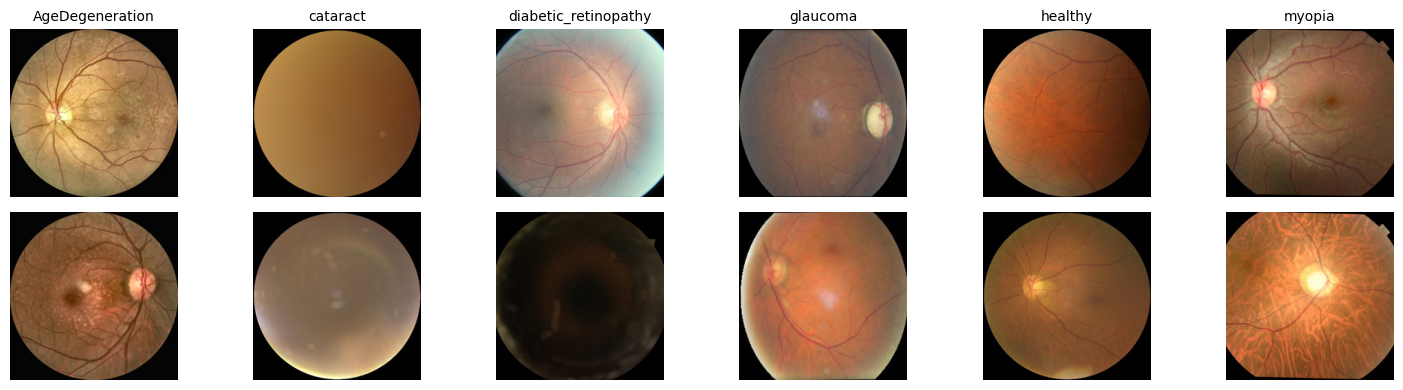

In [8]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Ruta del dataset preprocesado
DATASET_PATH = "dataset_preprocessed"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "myopia"
]

fig, axes = plt.subplots(2, len(classes), figsize=(15, 4))

for col, cls in enumerate(classes):
    class_path = os.path.join(DATASET_PATH, cls)
    
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ]
    
    selected_images = random.sample(images, 2)
    
    for row, img_name in enumerate(selected_images):
        img_path = os.path.join(class_path, img_name)
        
        img = Image.open(img_path).convert("RGB")
        
        axes[row, col].imshow(img)
        axes[row, col].axis("off")
        
        if row == 0:
            axes[row, col].set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()

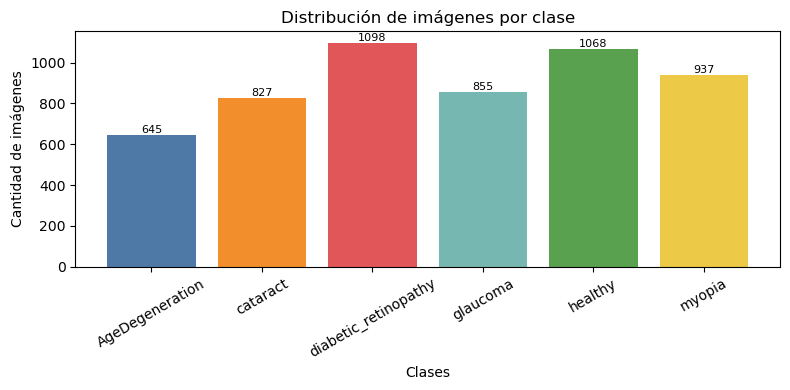

Cantidad de imágenes por clase:
- AgeDegeneration: 645
- cataract: 827
- diabetic_retinopathy: 1098
- glaucoma: 855
- healthy: 1068
- myopia: 937


In [10]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = "dataset_preprocessed"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "myopia"
]

image_counts = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".png", ".jpg", ".jpeg"))
    ])
    image_counts.append(count)

# ===== Gráfico =====
plt.figure(figsize=(8, 4))

# Colores personalizados
colors = [
    "#4E79A7",
    "#F28E2B",
    "#76B7B2",
    "#59A14F",
    "#EDC948"
]

bars = plt.bar(classes, image_counts, color=colors)

plt.xlabel("Clases")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase")
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print("Cantidad de imágenes por clase:")
for cls, count in zip(classes, image_counts):
    print(f"- {cls}: {count}")

**TÉCNICA DE BALANCEO DE CLASES**

In [11]:
import os
import random
from PIL import Image, ImageEnhance

# Parámetros generales
DATASET_PATH = "dataset_preprocessed"
TARGET_IMAGES = 1050
IMAGE_SIZE = 224
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

def augment_image(img):
    """Aplica transformaciones controladas a una imagen PIL"""

    # Rotación
    angle = random.uniform(-10, 10)
    img = img.rotate(angle, resample=Image.BILINEAR)

    # Brillo
    brightness_factor = random.uniform(0.9, 1.1)
    img = ImageEnhance.Brightness(img).enhance(brightness_factor)

    # Zoom
    w, h = img.size
    zoom_factor = random.uniform(0.9, 1.0)
    new_w, new_h = int(w * zoom_factor), int(h * zoom_factor)

    left = (w - new_w) // 2
    top = (h - new_h) // 2
    img = img.crop((left, top, left + new_w, top + new_h))

    # Redimensionar nuevamente
    img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.LANCZOS)

    return img

# Balanceo por clase
for class_name in os.listdir(DATASET_PATH):
    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(VALID_EXTENSIONS)
        and not img.startswith("aug_")
    ]

    current_count = len(images)

    if current_count >= TARGET_IMAGES:
        print(f" {class_name}: {current_count} imágenes (sin aumento)")
        continue

    needed = TARGET_IMAGES - current_count
    print(f" {class_name}: generando {needed} imágenes")

    generated = 0
    index = 0

    while generated < needed:
        img_name = images[index % current_count]
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path).convert("RGB")
            aug_img = augment_image(img)

            save_name = f"aug_{generated + 1:04d}.jpg"
            save_path = os.path.join(class_path, save_name)

            aug_img.save(save_path, quality=95)

            generated += 1
            index += 1

        except Exception as e:
            print(f"Error en {img_path}: {e}")
            index += 1

print("Balanceo de clases completado correctamente.")

 AgeDegeneration: generando 405 imágenes
 cataract: generando 223 imágenes
 diabetic_retinopathy: 1098 imágenes (sin aumento)
 glaucoma: generando 195 imágenes
 healthy: 1068 imágenes (sin aumento)
 myopia: generando 113 imágenes
Balanceo de clases completado correctamente.


**VISUALIZACIÓN DE IMÁGENES POR CLASE DEL DATASET BALANCEADO V.1**

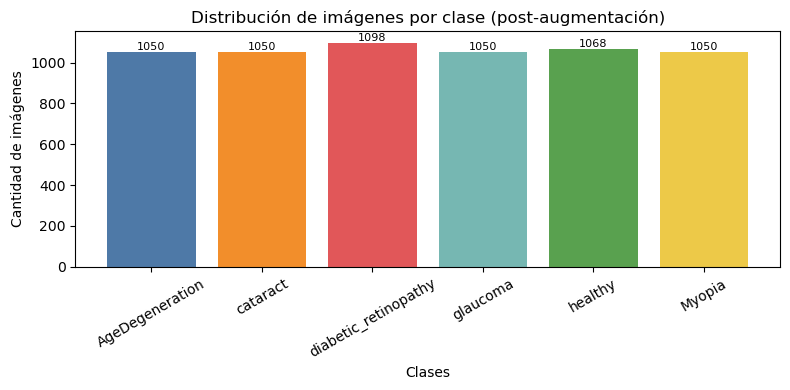

Cantidad de imágenes por clase (post-augmentación):
- AgeDegeneration: 1050
- cataract: 1050
- diabetic_retinopathy: 1098
- glaucoma: 1050
- healthy: 1068
- Myopia: 1050


In [12]:
import os
import matplotlib.pyplot as plt

DATASET_PATH = "dataset_preprocessed"

classes = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "Myopia"
]

image_counts = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    count = len([
        img for img in os.listdir(class_path)
        if img.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    image_counts.append(count)

# ===== Gráfico =====
plt.figure(figsize=(8, 4))

colors = [
    "#4E79A7",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
    "#59A14F",
    "#EDC948"
]

bars = plt.bar(classes, image_counts, color=colors)

plt.xlabel("Clases")
plt.ylabel("Cantidad de imágenes")
plt.title("Distribución de imágenes por clase (post-augmentación)")
plt.xticks(rotation=30)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height}",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.tight_layout()
plt.show()

print("Cantidad de imágenes por clase (post-augmentación):")
for cls, count in zip(classes, image_counts):
    print(f"- {cls}: {count}")

**RENOMBRAMIENTO DE LAS IMÁGENES DE CADA CLASE**

Para tener un mejor orden, se considero utilizar un correlativo para las imágenes *(Age Degeneration fueron renombradas como agedeg_001.jpg, agedeg_002.jpg, ...)*

In [13]:
import os
import shutil

SOURCE_DATASET = "dataset_preprocessed"
TARGET_DATASET = "dataset_renombrado" #Nuevo dataset renombrado las imágenes

class_prefix = {
    "AgeDegeneration": "agedeg",
    "cataract": "cataract",
    "diabetic_retinopathy": "dr",
    "glaucoma": "glaucoma",
    "healthy": "healthy",
    "myopia": "myopia"
}

valid_extensions = (".jpg", ".jpeg", ".png")

# Crear carpeta destino si no existe
os.makedirs(TARGET_DATASET, exist_ok=True)

for class_name, prefix in class_prefix.items():
    source_class_path = os.path.join(SOURCE_DATASET, class_name)
    target_class_path = os.path.join(TARGET_DATASET, class_name)
    
    os.makedirs(target_class_path, exist_ok=True)
    
    images = [
        img for img in os.listdir(source_class_path)
        if img.lower().endswith(valid_extensions)
    ]
    
    images.sort()
    
    print(f"Procesando clase {class_name}: {len(images)} imágenes")
    
    for idx, img_name in enumerate(images, start=1):
        ext = os.path.splitext(img_name)[1].lower()
        new_name = f"{prefix}_{idx:04d}{ext}"
        
        src_img_path = os.path.join(source_class_path, img_name)
        dst_img_path = os.path.join(target_class_path, new_name)
        
        shutil.copy2(src_img_path, dst_img_path)

Procesando clase AgeDegeneration: 1050 imágenes
Procesando clase cataract: 1050 imágenes
Procesando clase diabetic_retinopathy: 1098 imágenes
Procesando clase glaucoma: 1050 imágenes
Procesando clase healthy: 1068 imágenes
Procesando clase myopia: 1050 imágenes


- Como resultado de este proceso, se obtuvo un dataset normalizado, organizado y listo para su subdivisión en subconjuntos de entrenamiento, validación y prueba

**ORGANIZACIÓN FINAL DEL DATASET**

In [14]:
import os
import shutil
import random

INPUT_DATASET = "dataset_renombrado"
OUTPUT_DATASET = "dataset_final"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

CLASSES = [
    "AgeDegeneration",
    "cataract",
    "diabetic_retinopathy",
    "glaucoma",
    "healthy",
    "Myopia"
]

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png")

random.seed(42)

# ESTRUCTURA BASE
for split in ["train", "validation", "test"]:
    for class_name in CLASSES:
        os.makedirs(
            os.path.join(OUTPUT_DATASET, split, class_name),
            exist_ok=True
        )

# PROCESO DE DIVISIÓN
for class_name in CLASSES:
    class_path = os.path.join(INPUT_DATASET, class_name)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(VALID_EXTENSIONS)
    ]

    random.shuffle(images)
    total = len(images)

    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    print(f"\nClase: {class_name}")
    print(f"Total: {total}")
    print(f"Train: {len(train_images)} | Val: {len(val_images)} | Test: {len(test_images)}")

    # Copiar archivos
    for img in train_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(OUTPUT_DATASET, "train", class_name, img)
        )

    for img in val_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(OUTPUT_DATASET, "validation", class_name, img)
        )

    for img in test_images:
        shutil.copy(
            os.path.join(class_path, img),
            os.path.join(OUTPUT_DATASET, "test", class_name, img)
        )

print("\nDivisión del dataset completada correctamente.")


Clase: AgeDegeneration
Total: 1050
Train: 735 | Val: 157 | Test: 158

Clase: cataract
Total: 1050
Train: 735 | Val: 157 | Test: 158

Clase: diabetic_retinopathy
Total: 1098
Train: 768 | Val: 164 | Test: 166

Clase: glaucoma
Total: 1050
Train: 735 | Val: 157 | Test: 158

Clase: healthy
Total: 1068
Train: 747 | Val: 160 | Test: 161

Clase: Myopia
Total: 1050
Train: 735 | Val: 157 | Test: 158

División del dataset completada correctamente.


La división del dataset se realizó de manera estratificada por clase mediante un script desarrollado en Python, generando los subconjuntos de entrenamiento, validación y prueba en proporciones de 70%, 15% y 15%, respectivamente, asegurando la representatividad de cada categoría clínica.